In [ ]:
!pip -q install PyPortfolioOpt yfinance seaborn openpyxl

Activos con datos: ['AMZN', 'GEV', 'META', 'MSFT', 'MU', 'NVDA', 'QQQ', 'TQQQ']
NaNs por activo:
 Ticker
GEV     1568
AMZN       0
META       0
MSFT       0
MU         0
NVDA       0
QQQ        0
TQQQ       0
dtype: int64

Rango común: 2024-03-27 00:00:00 a 2026-03-19 00:00:00
NaNs final: 0


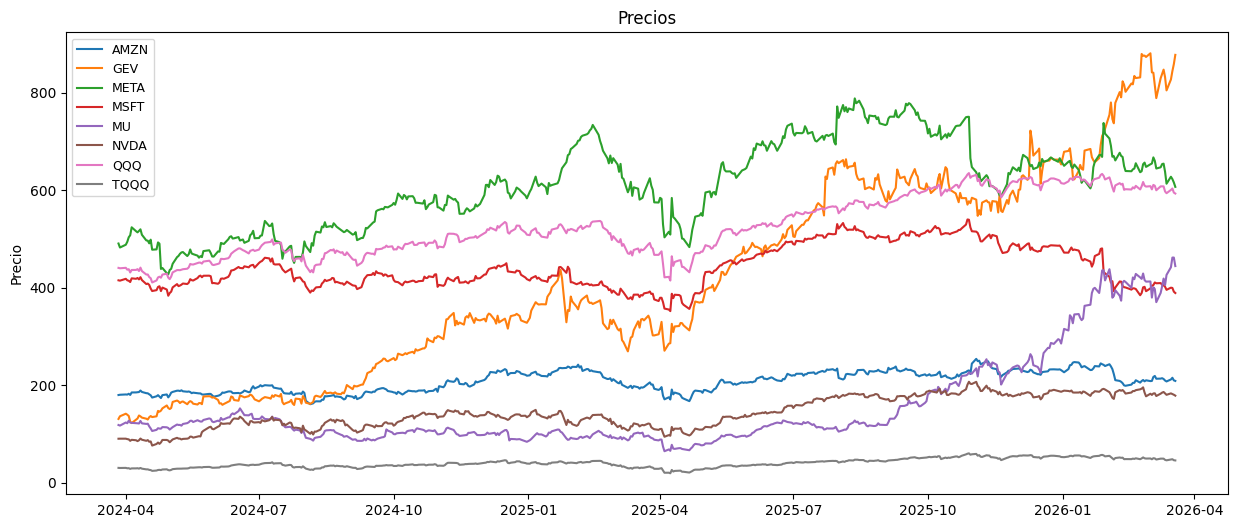

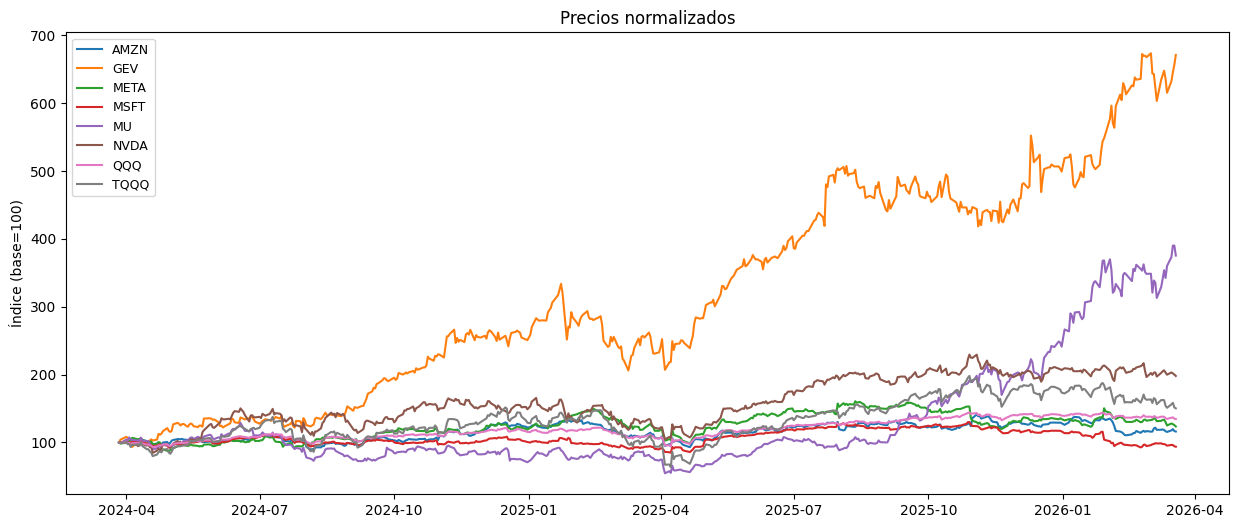

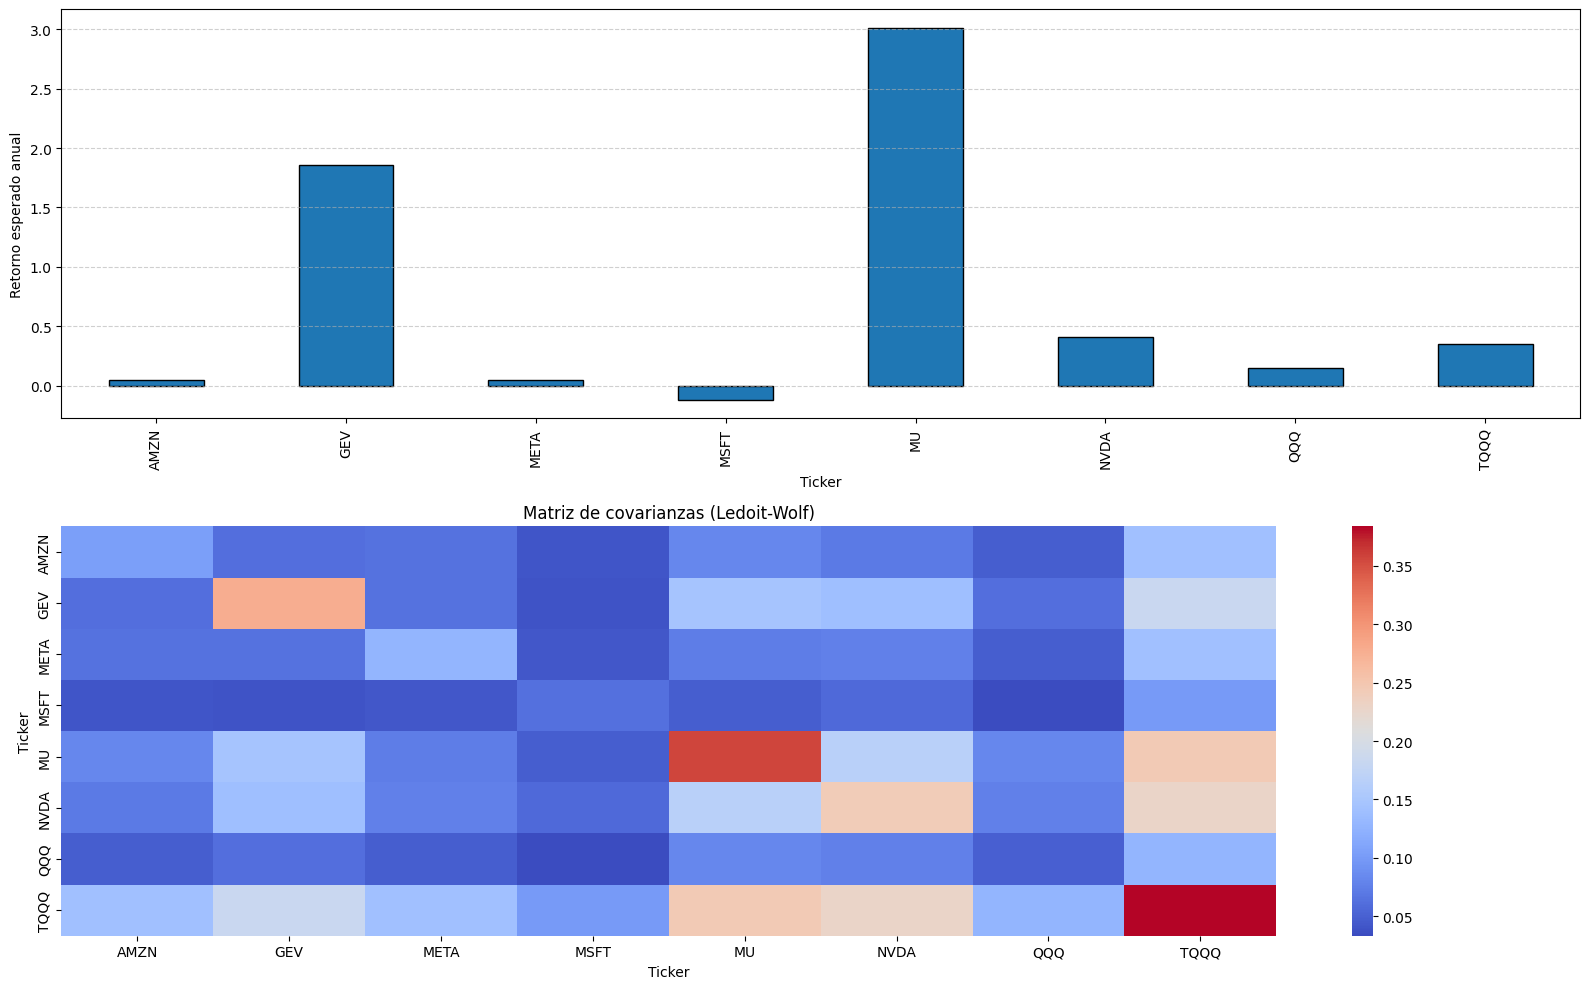


[DEBUG] target_ret_l2: 1.2444758601510961
[DEBUG] max_ret factible: 1.4092102739313523
[DEBUG] target_ret_l2 usado: 1.2444758601510961

Performance:
             Strategy  ExpectedAnnualReturn  AnnualVolatility    Sharpe
0           MaxSharpe              1.244476          0.320370  3.884494
1           L2_Stable              1.244476          0.323262  3.849745
2  MarketNeutral_0.20              0.200000          0.028948  6.908822
No se pudo calcular/plotear la frontera eficiente: Adding constraints to an already solved problem might have unintended consequences. A new instance should be created for the new set of constraints.

✅ Excel generado: portafolio_ideal.xlsx
Estrategia elegida: L2_Stable
Expected return: 124.45 %
Volatility: 32.33 %
Sharpe: 3.85
Leftover: 7.770101928712393

Asignación discreta:
  Asset  Number of Shares  LatestPrice  Total Invested
0    MU                32   444.269989    14216.639648
1   GEV                16   877.390015    14038.240234
2   QQQ          

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from pypfopt.expected_returns import ema_historical_return
from pypfopt.risk_models import CovarianceShrinkage
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import objective_functions
from pypfopt.discrete_allocation import DiscreteAllocation, get_latest_prices

# ==============================
# 0) Parámetros
# ==============================
activos = ["TQQQ","QQQ","NVDA","MSFT","META","AMZN","MU","GEV"]
fechaInicio = "2018-01-01"
hoy = datetime.today().strftime("%Y-%m-%d")
# Asignar monto a invertir en USD
total_portfolio_value = 56894.15
chosen_name = "L2_Stable"  # "MaxSharpe", "L2_Stable", "MarketNeutral_0.20"

# Para la estrategia MarketNeutral
target_return_mn = 0.20

# Para la L2
gamma_l2 = 0.1

# Constraint: mínimo NVDA
min_nvda = 0.03  # 3%

# Bounds long-only (máx 25% por activo)
long_bounds = (0, 0.25)

# ==============================
# 1) Descarga de precios (Adj Close auto_adjust)
# ==============================
px = yf.download(activos, start=fechaInicio, end=hoy, auto_adjust=True, progress=False)

df = px["Close"].copy() if isinstance(px.columns, pd.MultiIndex) else px[["Close"]].copy()
df = df.sort_index().dropna(axis=1, how="all")

print("Activos con datos:", list(df.columns))
print("NaNs por activo:\n", df.isna().sum().sort_values(ascending=False))

# ==============================
# 2) Alinear rango común y rellenar huecos
# ==============================
start_common = df.apply(lambda s: s.first_valid_index()).max()
end_common   = df.apply(lambda s: s.last_valid_index()).min()

df = df.loc[start_common:end_common].copy().ffill().bfill()

print("\nRango común:", start_common, "a", end_common)
print("NaNs final:", int(df.isna().sum().sum()))

assets = list(df.columns)

# ==============================
# 3) Gráficas (opcional)
# ==============================
plt.figure(figsize=(15,6))
for col in df.columns:
    plt.plot(df[col], label=col)
plt.legend(loc='upper left', fontsize=9)
plt.ylabel('Precio')
plt.title("Precios")
plt.show()

df_norm = df.divide(df.iloc[0]).mul(100)
plt.figure(figsize=(15,6))
for col in df_norm.columns:
    plt.plot(df_norm[col], label=col)
plt.legend(loc='upper left', fontsize=9)
plt.ylabel('Índice (base=100)')
plt.title("Precios normalizados")
plt.show()

# ==============================
# 4) mu y S
# ==============================
mu = ema_historical_return(df)            # anualizado (EMA)
S  = CovarianceShrinkage(df).ledoit_wolf()

plt.figure(figsize=(16,10))
plt.subplot(2,1,1)
mu.plot(kind='bar', edgecolor='black')
plt.ylabel("Retorno esperado anual")
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.subplot(2,1,2)
sns.heatmap(S, annot=False, cmap="coolwarm", cbar=True)
plt.title("Matriz de covarianzas (Ledoit-Wolf)")
plt.tight_layout()
plt.show()

# ==============================
# 5) Estrategias
# ==============================
# A) MaxSharpe (con mismos límites + NVDA mínimo) => target consistente
ef_a = EfficientFrontier(mu, S, weight_bounds=long_bounds)
ef_a.add_constraint(lambda w: w[assets.index("NVDA")] >= min_nvda)
w_a = ef_a.max_sharpe()
w_a_clean = ef_a.clean_weights()
perf_a = ef_a.portfolio_performance(verbose=False)

# B) L2_Stable (mismos límites + NVDA mínimo)
target_ret_l2 = perf_a[0]  # target consistente con restricciones

ef_b = EfficientFrontier(mu, S, weight_bounds=long_bounds)
ef_b.add_objective(objective_functions.L2_reg, gamma=gamma_l2)
ef_b.add_constraint(lambda w: w[assets.index("NVDA")] >= min_nvda)

# ✅ calcular retorno máximo factible (sin "resolver" antes) y recortar target si hace falta
ef_max = EfficientFrontier(mu, S, weight_bounds=long_bounds)
ef_max.add_constraint(lambda w: w[assets.index("NVDA")] >= min_nvda)
max_ret = ef_max._max_return()

target_ret_l2_fixed = min(target_ret_l2, max_ret - 1e-6)

ef_b.efficient_return(target_return=target_ret_l2_fixed)
w_b_clean = ef_b.clean_weights()
perf_b = ef_b.portfolio_performance(verbose=False)

print("\n[DEBUG] target_ret_l2:", target_ret_l2)
print("[DEBUG] max_ret factible:", max_ret)
print("[DEBUG] target_ret_l2 usado:", target_ret_l2_fixed)

# C) MarketNeutral (ojo: no se puede comprar discreto con shorts)
ef_c = EfficientFrontier(mu, S, weight_bounds=(-0.25, 0.25))
ef_c.efficient_return(target_return=target_return_mn, market_neutral=True)
w_c_clean = ef_c.clean_weights()
perf_c = ef_c.portfolio_performance(verbose=False)

# ==============================
# 6) Tabla de pesos + performance
# ==============================
def weights_to_series(w_dict, name):
    return pd.Series({a: float(w_dict.get(a, 0)) for a in assets}, name=name)

weights_df = pd.concat([
    weights_to_series(w_a_clean, "MaxSharpe"),
    weights_to_series(w_b_clean, "L2_Stable"),
    weights_to_series(w_c_clean, "MarketNeutral_0.20"),
], axis=1).T

perf_df = pd.DataFrame({
    "Strategy": ["MaxSharpe", "L2_Stable", "MarketNeutral_0.20"],
    "ExpectedAnnualReturn": [perf_a[0], perf_b[0], perf_c[0]],
    "AnnualVolatility":     [perf_a[1], perf_b[1], perf_c[1]],
    "Sharpe":               [perf_a[2], perf_b[2], perf_c[2]],
})

print("\nPerformance:")
print(perf_df)

# ==============================
# 7) Discrete Allocation (solo long)
# ==============================
latest_prices_all = get_latest_prices(df).dropna()

w_selected = weights_df.loc[chosen_name].astype(float)
chosen_weights = {a: float(w_selected[a]) for a in assets
                  if (a in latest_prices_all.index) and (w_selected[a] > 0)}

if len(chosen_weights) == 0:
    raise ValueError("chosen_weights quedó vacío. Revisa chosen_name o precios.")

common = list(chosen_weights.keys())
latest_prices = latest_prices_all.loc[common].dropna()

chosen_weights = {a: chosen_weights[a] for a in latest_prices.index}

s = sum(chosen_weights.values())
chosen_weights = {a: w/s for a, w in chosen_weights.items()}

da = DiscreteAllocation(chosen_weights, latest_prices, total_portfolio_value=total_portfolio_value)
allocation, leftover = da.lp_portfolio()

latest_prices_df = latest_prices.rename("LatestPrice").to_frame()

alloc_df = (
    pd.DataFrame({"Asset": list(allocation.keys()), "Number of Shares": list(allocation.values())})
      .merge(latest_prices_df, left_on="Asset", right_index=True, how="left")
)
alloc_df["Total Invested"] = alloc_df["Number of Shares"] * alloc_df["LatestPrice"]
alloc_df = alloc_df.sort_values("Total Invested", ascending=False).reset_index(drop=True)

# ==============================
# 8) Summary consistente con chosen_name
# ==============================
perf_map = {"MaxSharpe": perf_a, "L2_Stable": perf_b, "MarketNeutral_0.20": perf_c}
portfolio_return, portfolio_vol, portfolio_sharpe = perf_map[chosen_name]

portfolio_summary = pd.DataFrame({
    "Metric":[
        "Expected Annual Return (%)",
        "Annual Volatility (%)",
        "Sharpe Ratio",
        "Total Portfolio Value",
        "Cash Leftover"
    ],
    "Value":[
        portfolio_return*100,
        portfolio_vol*100,
        portfolio_sharpe,
        total_portfolio_value,
        leftover
    ]
})

# ==============================
# 9) Frontera eficiente
# ==============================
frontier_df = None
try:
    rets = np.linspace(float(mu.min()), float(mu.max()), 40)
    vols = []
    for r in rets:
        ef_tmp = EfficientFrontier(mu, S, weight_bounds=long_bounds)
        ef_tmp.add_constraint(lambda w: w[assets.index("NVDA")] >= min_nvda)
        # recorta target por si r es imposible
        max_ret_tmp = ef_tmp._max_return()
        r_use = min(float(r), float(max_ret_tmp) - 1e-6)
        ef_tmp.efficient_return(target_return=r_use)
        vols.append(ef_tmp.portfolio_performance(verbose=False)[1])

    sharpe_arr = rets / np.array(vols)
    frontier_df = pd.DataFrame({"Return": rets, "Volatility": vols, "Sharpe": sharpe_arr})

    plt.figure(figsize=(10,6))
    plt.scatter(frontier_df["Volatility"], frontier_df["Return"], c=frontier_df["Sharpe"], cmap="viridis")
    plt.colorbar(label="Sharpe")
    plt.xlabel("Volatilidad")
    plt.ylabel("Retorno")
    plt.title("Frontera eficiente (Markowitz)")
    plt.grid(True, alpha=0.3)
    plt.show()

except Exception as e:
    print("No se pudo calcular/plotear la frontera eficiente:", e)
    frontier_df = None

# ==============================
# 10) Exportar a Excel
# ==============================
output_path = "portafolio_ideal.xlsx"

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    weights_df.to_excel(writer, sheet_name="Weights")
    perf_df.to_excel(writer, sheet_name="Performance", index=False)
    latest_prices_df.to_excel(writer, sheet_name="LatestPrices")
    alloc_df.to_excel(writer, sheet_name="DiscreteAllocation", index=False)
    portfolio_summary.to_excel(writer, sheet_name="PortfolioSummary", index=False)
    mu.to_frame("mu").to_excel(writer, sheet_name="Mu")
    S.to_excel(writer, sheet_name="Covariance")
    if frontier_df is not None:
        frontier_df.to_excel(writer, sheet_name="EfficientFrontier", index=False)

print(f"\n✅ Excel generado: {output_path}")
print("Estrategia elegida:", chosen_name)
print("Expected return:", round(portfolio_return*100,2),"%")
print("Volatility:", round(portfolio_vol*100,2),"%")
print("Sharpe:", round(portfolio_sharpe,2))
print("Leftover:", leftover)

print("\nAsignación discreta:")
print(alloc_df)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pypfopt.efficient_frontier import EfficientFrontier

# --- 1) Frontera eficiente (Markowitz) ---
# Barrido de retornos objetivo (entre min y max de mu)
target_returns = np.linspace(mu.min(), mu.max(), 50)

frontier_rets = []
frontier_vols = []

for tr in target_returns:
    ef_tmp = EfficientFrontier(mu, S)  # crear uno nuevo en cada iteración
    try:
        ef_tmp.efficient_return(target_return=float(tr))
        r, v, _ = ef_tmp.portfolio_performance(verbose=False)
        frontier_rets.append(r)
        frontier_vols.append(v)
    except Exception:
        # si algún retorno objetivo no es factible, lo saltamos
        continue

frontier_rets = np.array(frontier_rets)
frontier_vols = np.array(frontier_vols)

# --- 2) Portafolios clave ---
# Max Sharpe (ya lo calculaste, pero lo recalculo aquí para tener coordenadas seguras)
ef_ms = EfficientFrontier(mu, S)
ef_ms.max_sharpe()
ms_ret, ms_vol, ms_sharpe = ef_ms.portfolio_performance(verbose=False)

# Min Volatility (muy útil como referencia)
ef_mv = EfficientFrontier(mu, S)
ef_mv.min_volatility()
mv_ret, mv_vol, mv_sharpe = ef_mv.portfolio_performance(verbose=False)

# Tus otros portafolios (si ya los tienes calculados)
# perf_a, perf_b, perf_c = (ret, vol, sharpe)
a_ret, a_vol, a_sh = perf_a
b_ret, b_vol, b_sh = perf_b
c_ret, c_vol, c_sh = perf_c

# --- 3) Puntos de los activos individuales ---
asset_rets = mu.values
asset_vols = np.sqrt(np.diag(S.values))  # volatilidad anual por activo

# --- 4) Plot ---
plt.figure(figsize=(14, 8))

# Frontera eficiente
plt.plot(frontier_vols, frontier_rets, linewidth=2, label="Frontera eficiente (Markowitz)")

# Activos
plt.scatter(asset_vols, asset_rets, marker="x", s=80, label="Activos")
for i, ticker in enumerate(mu.index):
    plt.annotate(ticker, (asset_vols[i], asset_rets[i]), fontsize=9, xytext=(5, 5), textcoords="offset points")

# Portafolios (marcadores)
plt.scatter(ms_vol, ms_ret, s=140, marker="*", label=f"MaxSharpe (Sharpe={ms_sharpe:.2f})")
plt.scatter(mv_vol, mv_ret, s=120, marker="D", label="MinVolatility")

plt.scatter(a_vol, a_ret, s=110, marker="o", label=f"Tu MaxSharpe (Sharpe={a_sh:.2f})")
plt.scatter(b_vol, b_ret, s=110, marker="s", label=f"L2_Stable (Sharpe={b_sh:.2f})")
plt.scatter(c_vol, c_ret, s=110, marker="^", label=f"MarketNeutral_0.20 (Sharpe={c_sh:.2f})")

plt.xlabel("Volatilidad anual")
plt.ylabel("Retorno anual esperado")
plt.title("Frontera eficiente de Markowitz + Activos + Portafolios")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()